In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

plt.rcParams["figure.figsize"] = (12,6)

print("Performance Analytics Environment Ready!")

Performance Analytics Environment Ready!


In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(nav.shape)
print(benchmark.shape)

(46000, 3)
(8050, 3)


In [3]:
nav["date"] = pd.to_datetime(nav["date"])

nav_pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

daily_returns = nav_pivot.pct_change()

daily_returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680


In [4]:
daily_returns.describe()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
count,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,...,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000
mean,0.000142,0.000170,0.001080,0.000852,0.000424,0.000242,0.000674,0.000110,0.000645,0.000865,...,0.001082,0.000256,0.000710,0.000477,0.001074,0.000825,0.001124,0.000522,0.001055,0.001194
std,0.009164,0.002460,0.011929,0.009177,0.016251,0.000319,0.008086,0.011424,0.009927,0.008913,...,0.010008,0.000323,0.009241,0.011561,0.008941,0.009719,0.011134,0.009042,0.011179,0.015648
min,-0.024744,-0.008188,-0.044238,-0.038121,-0.051847,-0.000766,-0.021104,-0.036695,-0.031271,-0.028490,...,-0.029748,-0.000704,-0.031505,-0.045218,-0.029451,-0.026127,-0.031266,-0.036676,-0.030092,-0.048870
25%,-0.006282,-0.001445,-0.006654,-0.005733,-0.010799,0.000020,-0.004931,-0.008096,-0.006277,-0.005285,...,-0.005857,0.000021,-0.005546,-0.007360,-0.004796,-0.006056,-0.006533,-0.005441,-0.006437,-0.008741
50%,-0.000070,0.000099,0.001086,0.000808,0.000182,0.000249,0.000632,0.000472,0.000390,0.000969,...,0.001081,0.000258,0.000431,0.000753,0.001289,0.000914,0.000727,0.000432,0.001239,0.000987
75%,0.006523,0.001824,0.008844,0.007165,0.011286,0.000456,0.006076,0.008108,0.007177,0.007152,...,0.007745,0.000482,0.006995,0.008171,0.007100,0.007207,0.008984,0.006639,0.008945,0.011440
max,0.032145,0.008837,0.041954,0.033956,0.054851,0.001247,0.025565,0.040745,0.032386,0.028218,...,0.033554,0.001254,0.028407,0.036193,0.030025,0.031415,0.039176,0.029362,0.041995,0.048490


### Insight 1

Daily return distributions exhibited relatively low average returns and moderate volatility, reflecting the diversified nature of mutual fund investments.


In [5]:
cagr_results = []

for fund in nav_pivot.columns:
    nav_series = nav_pivot[fund].dropna()

    start_nav = nav_series.iloc[0]
    end_nav = nav_series.iloc[-1]

    years = (nav_series.index[-1] - nav_series.index[0]).days / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_results.append({
        "amfi_code": fund,
        "cagr_pct": cagr
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [6]:
cagr_df.sort_values(
    by="cagr_pct",
    ascending=False
).head(10)

,amfi_code,cagr_pct
25,120505,32.827406
21,119598,32.423536
39,149324,32.287440
36,148569,31.949523
34,148567,30.974108
30,120843,30.907455
2,100033,30.123153
38,149323,29.581087
16,119094,28.214417
19,119551,25.804686


### Insight 2

Several mutual funds delivered strong annualized growth rates, demonstrating their long-term wealth creation potential.

In [7]:
risk_free_daily = 0.065 / 252

sharpe_ratio = (
    (daily_returns.mean() - risk_free_daily)
    / daily_returns.std()
) * np.sqrt(252)

sharpe_df = sharpe_ratio.reset_index()
sharpe_df.columns = ["amfi_code", "sharpe_ratio"]

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [8]:
sharpe_df.sort_values(
    by="sharpe_ratio",
    ascending=False
).head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


### Insight 3

Funds with higher Sharpe Ratios generated superior risk-adjusted returns relative to their volatility levels.

In [9]:
# Downside returns
downside_returns = daily_returns.copy()

downside_returns[downside_returns > 0] = 0

# Downside deviation
downside_std = downside_returns.std()

# Sortino Ratio
sortino_ratio = (
    (daily_returns.mean() - risk_free_daily)
    / downside_std
) * np.sqrt(252)

sortino_df = sortino_ratio.reset_index()
sortino_df.columns = ["amfi_code", "sortino_ratio"]

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.357702
1,100025,-1.009643
2,100033,1.967316
3,101206,1.889576
4,101207,0.285576


In [10]:
sortino_df.sort_values(
    by="sortino_ratio",
    ascending=False
).head(10)

,amfi_code,sortino_ratio
34,148567,2.609850
30,120843,2.463887
36,148569,2.278106
19,119551,2.243325
25,120505,2.158384
38,149323,2.011887
2,100033,1.967316
9,118632,1.961986
3,101206,1.889576
24,120504,1.877411


### Insight 4

Funds with higher Sortino Ratios effectively generated returns while limiting downside risk exposure.

In [11]:
print(benchmark.head())
print(benchmark.columns)
print(benchmark.shape)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
Index(['date', 'index_name', 'close_value'], dtype='str')
(8050, 3)


In [12]:
# Convert benchmark date
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Filter NIFTY100
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Calculate benchmark returns
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100 = nifty100[
    ["date", "benchmark_return"]
]

nifty100.head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [13]:
alpha_beta_results = []

for fund in daily_returns.columns:

    fund_returns = daily_returns[fund].reset_index()
    fund_returns.columns = ["date", "fund_return"]

    merged = pd.merge(
        fund_returns,
        nifty100,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 30:

        slope, intercept, r, p, stderr = linregress(
            merged["benchmark_return"],
            merged["fund_return"]
        )

        beta = slope
        alpha = intercept * 252 * 100

        alpha_beta_results.append({
            "amfi_code": fund,
            "alpha_pct": alpha,
            "beta": beta
        })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,alpha_pct,beta
0,100016,3.747581,-0.058268
1,100025,4.281792,0.001158
2,100033,27.195355,0.005104
3,101206,21.399785,0.021086
4,101207,10.897092,-0.065289


In [14]:
alpha_beta_df.sort_values(
    by="alpha_pct",
    ascending=False
).head(10)

,amfi_code,alpha_pct,beta
21,119598,30.336965,-0.023196
39,149324,30.057878,0.011455
25,120505,29.263583,0.000549
36,148569,28.270368,0.018134
30,120843,27.330465,-0.022830
2,100033,27.195355,0.005104
34,148567,26.983751,0.023684
38,149323,26.598578,-0.002523
16,119094,26.076669,-0.066265
19,119551,23.201007,-0.031751


In [15]:
alpha_beta_df.sort_values(
    by="beta",
    ascending=False
).head(10)

,amfi_code,alpha_pct,beta
11,118634,17.500722,0.103497
22,119599,4.882422,0.062002
32,125497,17.729755,0.048820
26,120506,16.253853,0.041896
28,120841,13.042924,0.036356
15,119093,8.232801,0.025883
34,148567,26.983751,0.023684
3,101206,21.399785,0.021086
36,148569,28.270368,0.018134
29,120842,7.804439,0.018057


In [17]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


### Insight 5

Several funds generated positive alpha, indicating benchmark outperformance, while relatively low beta values suggested limited sensitivity to market fluctuations.

In [18]:
drawdown_results = []

for fund in nav_pivot.columns:

    nav_series = nav_pivot[fund].dropna()

    running_max = nav_series.cummax()

    drawdown = (nav_series / running_max) - 1

    max_drawdown = drawdown.min() * 100

    drawdown_results.append({
        "amfi_code": fund,
        "max_drawdown_pct": max_drawdown
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

,amfi_code,max_drawdown_pct
0,100016,-24.734441
1,100025,-4.308264
2,100033,-16.217209
3,101206,-11.291596
4,101207,-35.446916


In [19]:
drawdown_df.sort_values(
    by="max_drawdown_pct"
).head(10)

,amfi_code,max_drawdown_pct
22,119599,-52.574221
17,119095,-51.677754
4,101207,-35.446916
39,149324,-31.171900
21,119598,-28.706006
7,102886,-28.001124
0,100016,-24.734441
29,120842,-24.003511
11,118634,-23.344886
15,119093,-21.751396


In [ ]:
### Insight 6

Some funds experienced deeper drawdowns than others, highlighting differences in downside resilience during market corrections.

In [21]:
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

expense_df = performance[
    ["amfi_code", "expense_ratio_pct"]
]
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "alpha_pct"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    expense_df,
    on="amfi_code"
)

scorecard.head()

,amfi_code,cagr_pct,sharpe_ratio,alpha_pct,max_drawdown_pct,expense_ratio_pct
0,100016,2.637074,-0.201517,3.747581,-24.734441,1.55
1,100025,4.458210,-0.567095,4.281792,-4.308264,0.56
2,100033,30.123153,1.093699,27.195355,-16.217209,1.38
3,101206,23.538361,1.027213,21.399785,-11.291596,1.60
4,101207,7.938765,0.162661,10.897092,-35.446916,1.53


In [23]:
scorecard["return_rank"] = scorecard["cagr_pct"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha_pct"].rank(
    ascending=False
)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

scorecard["drawdown_rank"] = scorecard["max_drawdown_pct"].rank(
    ascending=False
)
scorecard["fund_score"] = (
    scorecard["return_rank"] * 0.30 +
    scorecard["sharpe_rank"] * 0.25 +
    scorecard["alpha_rank"] * 0.20 +
    scorecard["expense_rank"] * 0.15 +
    scorecard["drawdown_rank"] * 0.10
)

scorecard["fund_score"] = (
    100 -
    (scorecard["fund_score"] / scorecard["fund_score"].max()) * 100
).round(2)

scorecard.head()

,amfi_code,cagr_pct,sharpe_ratio,alpha_pct,max_drawdown_pct,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,100016,2.637074,-0.201517,3.747581,-24.734441,1.55,37.0,35.0,39.0,32.0,34.0,0.90
1,100025,4.458210,-0.567095,4.281792,-4.308264,0.56,36.0,39.0,38.0,2.0,4.0,20.25
2,100033,30.123153,1.093699,27.195355,-16.217209,1.38,7.0,7.0,6.0,17.0,20.0,73.46
3,101206,23.538361,1.027213,21.399785,-11.291596,1.60,12.0,9.0,12.0,36.5,9.0,59.57
4,101207,7.938765,0.162661,10.897092,-35.446916,1.53,27.0,28.0,27.0,28.5,38.0,21.01


In [24]:
scorecard["fund_score"] = (
    scorecard["return_rank"] * 0.30 +
    scorecard["sharpe_rank"] * 0.25 +
    scorecard["alpha_rank"] * 0.20 +
    scorecard["expense_rank"] * 0.15 +
    scorecard["drawdown_rank"] * 0.10
)

scorecard["fund_score"] = (
    100 -
    (scorecard["fund_score"] / scorecard["fund_score"].max()) * 100
).round(2)

scorecard.head()

,amfi_code,cagr_pct,sharpe_ratio,alpha_pct,max_drawdown_pct,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,100016,2.637074,-0.201517,3.747581,-24.734441,1.55,37.0,35.0,39.0,32.0,34.0,0.90
1,100025,4.458210,-0.567095,4.281792,-4.308264,0.56,36.0,39.0,38.0,2.0,4.0,20.25
2,100033,30.123153,1.093699,27.195355,-16.217209,1.38,7.0,7.0,6.0,17.0,20.0,73.46
3,101206,23.538361,1.027213,21.399785,-11.291596,1.60,12.0,9.0,12.0,36.5,9.0,59.57
4,101207,7.938765,0.162661,10.897092,-35.446916,1.53,27.0,28.0,27.0,28.5,38.0,21.01


In [25]:
scorecard.sort_values(
    by="fund_score",
    ascending=False
).head(10)


,amfi_code,cagr_pct,sharpe_ratio,alpha_pct,max_drawdown_pct,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
25,120505,32.827406,1.180101,29.263583,-18.188514,1.36,1.0,5.0,3.0,15.0,25.0,80.93
34,148567,30.974108,1.448291,26.983751,-11.265729,1.46,5.0,1.0,7.0,23.0,8.0,79.54
30,120843,30.907455,1.306744,27.330465,-12.973968,1.45,6.0,2.0,5.0,22.0,13.0,78.16
2,100033,30.123153,1.093699,27.195355,-16.217209,1.38,7.0,7.0,6.0,17.0,20.0,73.46
36,148569,31.949523,1.234930,28.270368,-16.396743,1.60,4.0,3.0,4.0,36.5,21.0,71.46
21,119598,32.423536,0.945308,30.336965,-28.706006,1.43,2.0,14.0,1.0,21.0,36.0,69.45
24,120504,23.295119,1.026524,21.194827,-12.588276,0.80,13.0,10.0,13.0,12.0,12.0,66.83
20,119552,21.524236,0.953279,19.868599,-11.803494,0.66,15.0,12.0,15.0,4.0,11.0,66.28
39,149324,32.287440,0.949796,30.057878,-31.171900,1.52,3.0,13.0,2.0,26.5,37.0,66.21
19,119551,25.804686,1.208267,23.201007,-15.012385,1.54,10.0,4.0,10.0,30.5,17.0,66.07


In [26]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


In [ ]:
### Insight 7

The composite scorecard identified funds that consistently balanced returns, risk-adjusted performance, cost efficiency, and downside protection.

In [27]:
top5 = scorecard.sort_values(
    by="fund_score",
    ascending=False
).head(5)

top5["amfi_code"]

25    120505
34    148567
30    120843
2     100033
36    148569
Name: amfi_code, dtype: int64

In [28]:
top5["amfi_code"]

25    120505
34    148567
30    120843
2     100033
36    148569
Name: amfi_code, dtype: int64

In [29]:
top5 = scorecard.sort_values(
    by="fund_score",
    ascending=False
).head(5)

top5_codes = top5["amfi_code"].tolist()

print(top5_codes)

[120505, 148567, 120843, 100033, 148569]


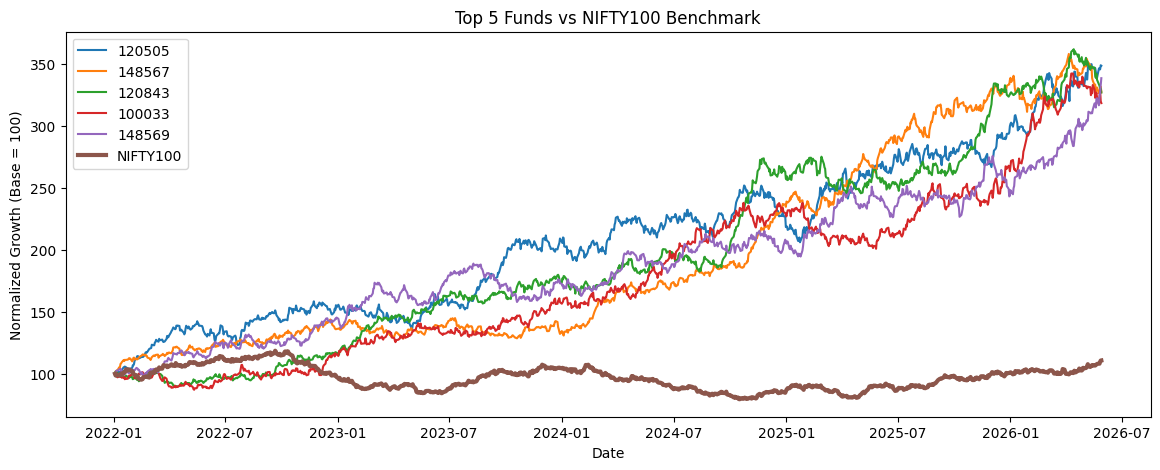

In [31]:
plt.figure(figsize=(14,5))

# Plot Top 5 Funds
for code in top5_codes:
    normalized_nav = (
        nav_pivot[code] / nav_pivot[code].dropna().iloc[0]
    ) * 100

    plt.plot(
        normalized_nav.index,
        normalized_nav,
        label=str(code)
    )

# NIFTY100
nifty100_prices = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100_prices["date"] = pd.to_datetime(nifty100_prices["date"])

nifty100_prices.set_index("date", inplace=True)

nifty100_normalized = (
    nifty100_prices["close_value"]
    / nifty100_prices["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100_normalized.index,
    nifty100_normalized,
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY100 Benchmark")
plt.xlabel("Date")
plt.ylabel("Normalized Growth (Base = 100)")
plt.legend()

plt.show()

### Insight 8
Several top-ranked funds outperformed the benchmark over the study period, demonstrating their ability to generate superior long-term returns.

In [32]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("All Day 4 outputs saved successfully!")

All Day 4 outputs saved successfully!
